DATA VIZ

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import torch

BASE = "./chest_xray/chest_xray"
classes = ["NORMAL", "PNEUMONIA"]
SOURCE_SPLITS = ["train", "val", "test"]   # Kaggle's original splits — we merge all 3 and re-split 80/10/10
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
BATCH_SIZE = 32
IMG_SIZE = 224

# Seed every RNG source so splits, sampling and training are
# reproducible across machines (Python random, NumPy, PyTorch CPU + CUDA)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

# The Kaggle dataset ships pre-split into train/val/test, but the original val set
# is tiny (16 images). We walk all three subfolders and build our own 80/10/10 split.
# Each entry is stored as a path RELATIVE to BASE (e.g. "train/NORMAL/IM-0001.jpeg")
# so the Dataset class can rebuild the full image path with a single os.path.join.
all_files = {}
for cls in classes:
    relative_paths = []
    for split in SOURCE_SPLITS:
        cls_dir = os.path.join(BASE, split, cls)

        # sorted() makes os.listdir deterministic across filesystems (APFS / ext4 / NTFS
        # each return entries in a different order), so random.shuffle below produces
        # the same split on every machine.
        for f in sorted(os.listdir(cls_dir)):
            if os.path.splitext(f)[1].lower() in IMAGE_EXTS:
                relative_paths.append(os.path.join(split, cls, f))
    random.shuffle(relative_paths)
    all_files[cls] = relative_paths

splits_data = {"train": {}, "val": {}, "test": {}}
for cls, files in all_files.items():
    n = len(files)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    splits_data["train"][cls] = files[:n_train]
    splits_data["val"][cls]   = files[n_train:n_train + n_val]
    splits_data["test"][cls]  = files[n_train + n_val:]


In [2]:
def summarize_splits(splits_data):
    print("\nDataset Summary")

    total = 0

    for split_name, split in splits_data.items():
        print(f"\n{split_name.upper()}:")

        split_total = 0

        for cls, files in split.items():
            count = len(files)
            split_total += count
            print(f"  {cls}: {count}")

        total += split_total
        print(f"  ➜ Total: {split_total}")

    print(f"\nOverall total images: {total}")


summarize_splits(splits_data)


Dataset Summary

TRAIN:
  NORMAL: 1266
  PNEUMONIA: 3418
  ➜ Total: 4684

VAL:
  NORMAL: 158
  PNEUMONIA: 427
  ➜ Total: 585

TEST:
  NORMAL: 159
  PNEUMONIA: 428
  ➜ Total: 587

Overall total images: 5856


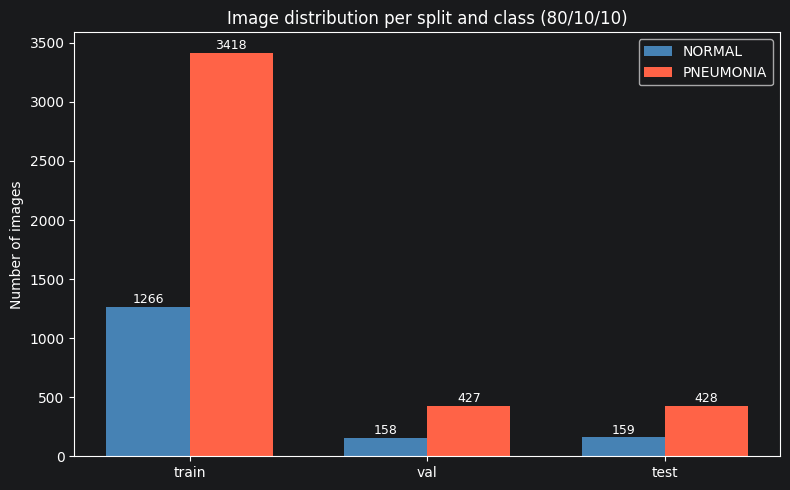

In [3]:
splits = ["train", "val", "test"]
counts = {split: {cls: len(splits_data[split][cls]) for cls in classes} for split in splits}

x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [counts[s]["NORMAL"]    for s in splits], width, label="NORMAL",    color="steelblue")
bars2 = ax.bar(x + width/2, [counts[s]["PNEUMONIA"] for s in splits], width, label="PNEUMONIA", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of images")
ax.set_title("Image distribution per split and class (80/10/10)")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Show some lungs :)

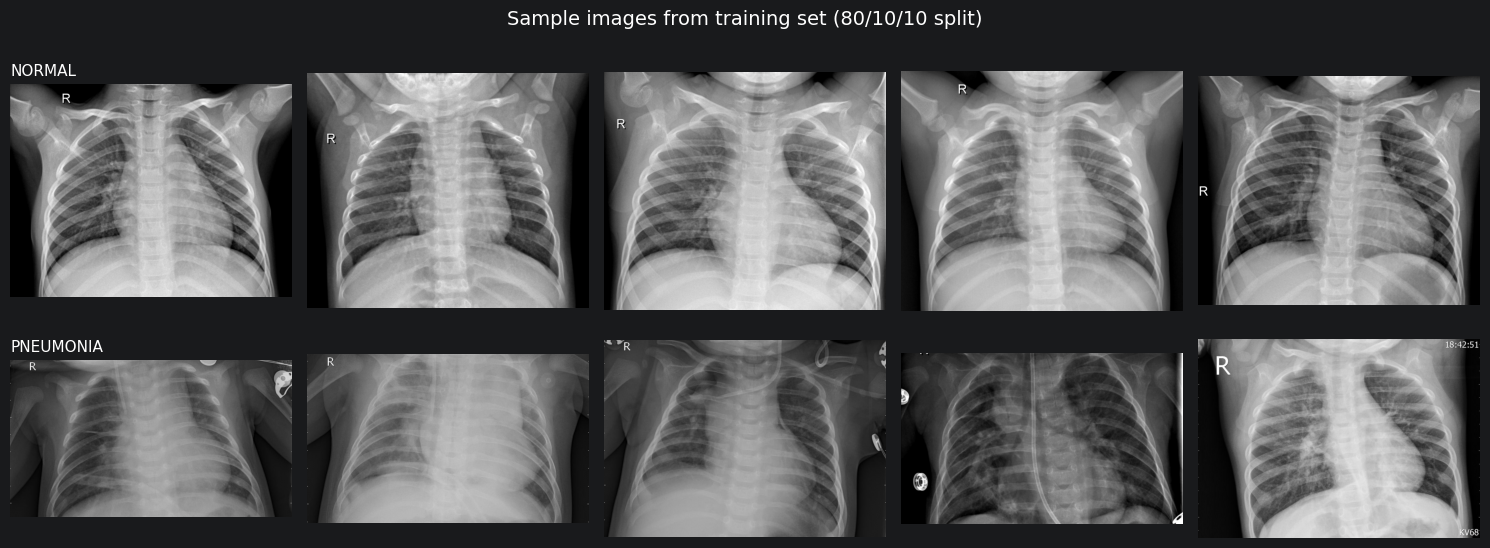

In [4]:
# Show sample images from the training split
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample images from training set (80/10/10 split)", fontsize=14)

for row, cls in enumerate(classes):  # 0 = NORMAL, 1 = PNEUMONIA
    files = splits_data["train"][cls][:5]
    for col, relative_path in enumerate(files):  # relative_path: "train/NORMAL/IM-0001.jpeg"
        img = mpimg.imread(os.path.join(BASE, relative_path))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, loc="left")

plt.tight_layout()
plt.show()

Show class distribution

In [5]:
# Total count per class across train/val/test
class_totals = {}

for cls in classes:
    total = 0

    for split in splits:
        total += counts[split][cls]

    class_totals[cls] = total
class_totals

{'NORMAL': 1583, 'PNEUMONIA': 4273}

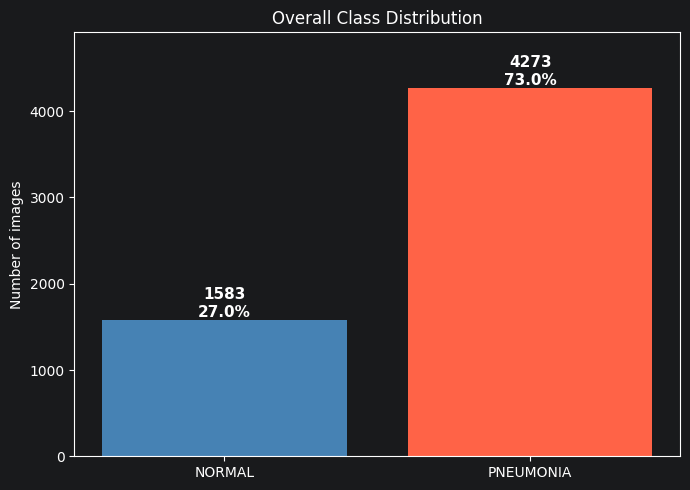

Class distribution:
NORMAL: 1583 images (27.0%)
PNEUMONIA: 4273 images (73.0%)


In [6]:
total_images = sum(class_totals.values())

class_names = ["NORMAL", "PNEUMONIA"]
values = [class_totals[key] for key in class_names]
percentages = [(value / total_images) * 100 for value in values]

colors = ["steelblue", "tomato"]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(class_names, values, color=colors)

ax.set_title("Overall Class Distribution")
ax.set_ylabel("Number of images")
ax.set_ylim(0, max(values) * 1.15)

# Add count and percentage labels above bars
for bar, count, pct in zip(bars, values, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("Class distribution:")
for name, count, pct in zip(class_names, values, percentages):
    print(f"{name}: {count} images ({pct:.1f}%)")

There's a clear class imbalance here, we need to handle this

**Preprocessing**

Keep images to the 224x224 standard

In [7]:
import os
import torch
from PIL import Image, ImageOps
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt


print(f"Using fixed resize target: {IMG_SIZE}x{IMG_SIZE}px")

# Detect hardware: CUDA (NVIDIA GPUs), MPS (Apple Silicon M1/M2/M3), or CPU fallback
import platform

if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"Using device: CUDA — {device_name}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon — {platform.processor() or platform.machine()})")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU ({platform.processor() or platform.machine()})")

print(f"PyTorch version: {torch.__version__}")
print(f"Platform: {platform.system()} {platform.release()}")

class PadToSquare: #Example 1000x500 turns to 1000 x 1000 px, prevents stretching before resizing
    def __init__(self, fill=0):
        self.fill = fill

    def __call__(self, image):
        width, height = image.size

        if width == height:
            return image

        max_side = max(width, height)

        padding_left = (max_side - width) // 2
        padding_right = max_side - width - padding_left
        padding_top = (max_side - height) // 2
        padding_bottom = max_side - height - padding_top

        padding = (
            padding_left,
            padding_top,
            padding_right,
            padding_bottom
        )

        return ImageOps.expand(image, padding, fill=self.fill)

Using fixed resize target: 224x224px
Using device: CUDA — NVIDIA GeForce RTX 5070 Laptop GPU
PyTorch version: 2.11.0+cu130
Platform: Windows 10


In [8]:
train_transform = transforms.Compose([ #Input example: Blue x-ray 1200 x 800 px
    transforms.Grayscale(num_output_channels=3), # gray-scaled x-ray 1200 x 800
    PadToSquare(fill=0), # 1200x1200 (black bars added)
    transforms.Resize((IMG_SIZE, IMG_SIZE)), #resized to 224x224

    # Light augmentation only
    transforms.RandomAffine(
        degrees=7, # rotate between -7 and - 7 degrees
        translate=(0.03, 0.03), # Moves the img horizontally or vertically up to 3% of the image height
        scale=(0.97, 1.03) #zoom between 97% and 103%
    ),

    transforms.ToTensor(),

    # ImageNet normalization if using pretrained CNNs later.
    # Also works fine with 3-channel grayscale images.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

##Setup for validation setup, no rotation, scaling neccesary here.
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    PadToSquare(fill=0),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
class ChestXrayCombineClasses(torch.utils.data.Dataset):
    def __init__(self, base_dir, split_files, classes, transform=None):
        self.base_dir = base_dir
        self.split_files = split_files
        self.classes = classes
        self.transform = transform

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(classes)
        }

        self.samples = []

        # split_files[cls] holds paths RELATIVE to base_dir (e.g. "train/NORMAL/IM-0001.jpeg"),
        # so a single join rebuilds the full image path.
        for class_name in classes:
            label = self.class_to_idx[class_name]
            for relative_path in split_files[class_name]:
                image_path = os.path.join(base_dir, relative_path)
                self.samples.append((image_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

**GPU Memory Cache – Eliminating the Windows DataLoader Bottleneck**

On Windows, `num_workers=0` forces all image loading and transforms to run on the main
thread every epoch, which is why training takes ~3 min/epoch on an RTX 5070 while the
M1 Pro (which can use `num_workers=4` with fork) finishes in 20–30 s.

The fix: since all ~5 800 images at 224×224×3 float32 ≈ **1 GB** fit comfortably in
8 GB of VRAM, we pre-load every transformed tensor into GPU memory once. After that,
each `__getitem__` is a simple tensor index — no disk I/O, no PIL decoding, no
torchvision transforms — so the single-threaded DataLoader becomes effectively free.

**Note on augmentation:** training augmentations (random rotation, zoom, shift) are
applied once during caching, so each epoch sees the *same* augmented version. For this
dataset size and augmentation intensity this is acceptable; if you want fresh
augmentations every epoch you can call `cache.refresh()` between epochs (at the cost of
one slow re-load pass).

In [10]:
class CachedDataset(torch.utils.data.Dataset):
    """Wraps any map-style dataset by pre-loading all tensors into GPU memory.

    This eliminates per-batch disk I/O and CPU transforms during training,
    which is the main bottleneck when num_workers=0 on Windows.
    """
    def __init__(self, source_dataset, cache_device=None):
        self.samples = source_dataset.samples          # keep for WeightedRandomSampler
        # Fallback: prefer CUDA, then MPS (Apple Silicon), then CPU
        if cache_device is None:
            if torch.cuda.is_available():
                cache_device = "cuda"
            elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
                cache_device = "mps"
            else:
                cache_device = "cpu"

        images, labels = [], []
        print(f"Caching {len(source_dataset)} images to {cache_device} …", end=" ", flush=True)
        for i in range(len(source_dataset)):
            img, lbl = source_dataset[i]
            images.append(img)
            labels.append(lbl)

        # Stack into contiguous GPU tensors — one big allocation, very fast to index
        self.images = torch.stack(images).to(cache_device)
        self.labels = torch.tensor(labels, dtype=torch.long, device=cache_device)
        print("done.")

    def __len__(self):
        return self.images.size(0)

    def __getitem__(self, index):
        return self.images[index], self.labels[index]

    def refresh(self, source_dataset):
        """Re-cache from source (useful to get fresh random augmentations)."""
        images = []
        for i in range(len(source_dataset)):
            img, _ = source_dataset[i]
            images.append(img)
        self.images = torch.stack(images).to(self.images.device)

In [11]:
train_dataset = ChestXrayCombineClasses(
    base_dir=BASE,
    split_files=splits_data["train"],
    classes=classes,
    transform=train_transform
)

val_dataset = ChestXrayCombineClasses(
    base_dir=BASE,
    split_files=splits_data["val"],
    classes=classes,
    transform=eval_transform
)

test_dataset = ChestXrayCombineClasses(
    base_dir=BASE,
    split_files=splits_data["test"],
    classes=classes,
    transform=eval_transform
)
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

# Wrap datasets in GPU cache to eliminate per-epoch disk I/O (the Windows bottleneck)
train_dataset = CachedDataset(train_dataset, cache_device=device)
val_dataset   = CachedDataset(val_dataset,   cache_device=device)
test_dataset  = CachedDataset(test_dataset,   cache_device=device)

Train images: 4684
Validation images: 585
Test images: 587
Caching 4684 images to cuda … done.
Caching 585 images to cuda … done.
Caching 587 images to cuda … done.


**Handle class imbalance by using weighted random sampling**

In [12]:
train_labels = [label for _, label in train_dataset.samples]

class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts

sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

print("Training class counts:", class_counts)
print("Class weights:", class_weights)

Training class counts: [1266 3418]
Class weights: [0.00078989 0.00029257]


We only use the sampler on the training loader, here we want it to be good at both sick and normal classes. However we don't want to skew the real world distribution of sick and normal classes.

In [13]:
# Cross-platform DataLoader configuration.
#
# num_workers > 0 lets CPU processes prefetch and transform batches in parallel
# so the GPU/MPS isn't blocked waiting for PIL+torchvision on each batch.
#
# Per-platform behaviour:
#   - macOS (Darwin): default start method is "spawn", which makes worker
#     processes re-import the notebook and fail to find classes defined in
#     __main__ (e.g. ChestXrayCombineClasses). We override with "fork" so
#     workers inherit the running interpreter's in-memory classes.
#   - Linux (incl. WSL, Colab, Kaggle, NVIDIA boxes): "fork" is already the
#     default; we set it explicitly for consistency across the team.
#   - Windows: fork() does not exist (POSIX-only). spawn() would hit the
#     same __main__ re-import issue, so we fall back to num_workers=0
#     (single-threaded data loading). Reliable but slower. The proper fix
#     for parallel loading on Windows would be to move the dataset class
#     to a separate .py module — which conflicts with project guideline #1.
import multiprocessing
import platform

if platform.system() == "Windows":
    num_workers = 0
    mp_ctx = None
else:
    num_workers = 4
    mp_ctx = multiprocessing.get_context("fork")

loader_kwargs = dict(
    num_workers=num_workers,
    # pin_memory is unnecessary when tensors are already cached on the GPU
    pin_memory=False,
    persistent_workers=(num_workers > 0),
)
if mp_ctx is not None:
    loader_kwargs["multiprocessing_context"] = mp_ctx

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

Print images, convert back from tensor to display correctly

This cell was slow because next(iter(train_loader)) starts DataLoader worker processes and applies transforms just to preview one batch.
Previewing directly from train_dataset avoids the DataLoader multiprocessing startup overhead.


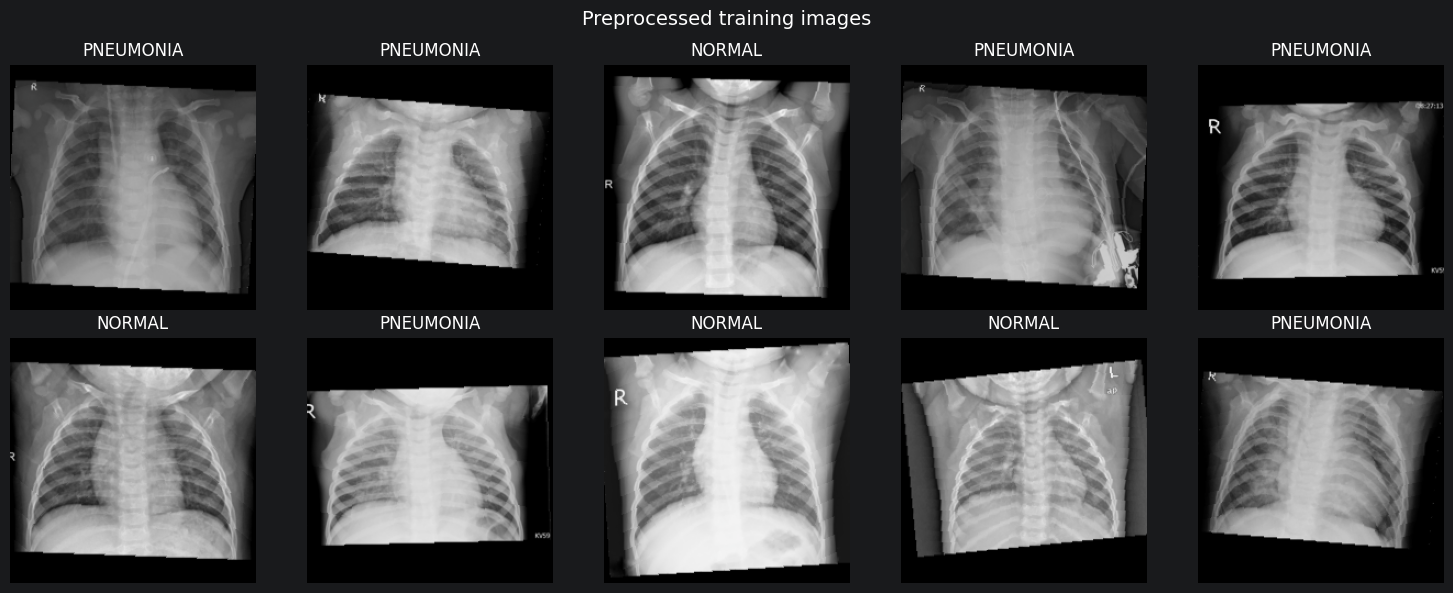

In [14]:
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=tensor.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=tensor.device).view(3, 1, 1)

    image = tensor * std + mean
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).cpu().numpy()


print("This cell was slow because next(iter(train_loader)) starts DataLoader worker processes and applies transforms just to preview one batch.")
print("Previewing directly from train_dataset avoids the DataLoader multiprocessing startup overhead.")

preview_indices = torch.multinomial(
    torch.DoubleTensor(sample_weights),
    num_samples=10,
    replacement=True
).tolist()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Preprocessed training images", fontsize=14)

for dataset_index, ax in zip(preview_indices, axes.flat):
    image_tensor, label = train_dataset[dataset_index]
    image = denormalize_image(image_tensor)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

**Model Definition – Custom CNN for Pneumonia Classification**

We use a simple 3-block CNN with batch normalization and dropout to classify chest X-rays as NORMAL (0) or PNEUMONIA (1).

In [15]:
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import copy, time

# Custom CNN with 3 conv blocks, batch norm, and dropout
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 3 -> 32 channels
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 32 -> 64 channels
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 64 -> 128 channels
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

        )
        # After 3x MaxPool2d(2): 224 -> 112 -> 56 -> 28, so feature map is 128*28*28
        self.fc = nn.Sequential(
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)  # 2 classes: NORMAL, PNEUMONIA
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)  # flatten
        return self.fc(x)

model = PneumoniaCNN().to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

PneumoniaCNN(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=100352, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_featur

**Training Setup**

- Loss: CrossEntropyLoss (sampler already handles class imbalance)
- Optimizer: Adam with lr=1e-4
- Scheduler: ReduceLROnPlateau (patience=2, factor=0.5) — automatically reduces the learning rate when validation loss plateaus, preventing overshooting and improving convergence.
- We track loss, accuracy, recall, and precision each epoch for both train and val sets.

In [16]:
# Training hyperparameters
NUM_EPOCHS = 15
LR = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Storage for metrics per epoch
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "train_recall": [], "val_recall": [],
    "train_precision": [], "val_precision": [],
}

best_val_loss = float('inf')
best_model_weights = None

**Training Loop**

Each epoch: train on batches, then evaluate on validation set. We save the best model (lowest val loss).

In [17]:
def compute_metrics(all_labels, all_preds):
    """Compute accuracy, recall (sensitivity), and precision from label/pred lists."""
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0       # sensitivity
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    return acc, recall, precision

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # --- Training phase ---
    model.train()
    running_loss = 0.0
    train_preds, train_labels = [], []

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().numpy())

    train_loss = running_loss / len(train_dataset)
    train_acc, train_recall, train_prec = compute_metrics(train_labels, train_preds)

    # --- Validation phase ---
    model.eval()
    val_running_loss = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc, val_recall, val_prec = compute_metrics(val_labels, val_preds)

    # Step the learning rate scheduler based on validation loss
    scheduler.step(val_loss)

    # Save metrics
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_recall"].append(train_recall)
    history["val_recall"].append(val_recall)
    history["train_precision"].append(train_prec)
    history["val_precision"].append(val_prec)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_weights = copy.deepcopy(model.state_dict())

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} Rec: {train_recall:.3f} Prec: {train_prec:.3f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} Rec: {val_recall:.3f} Prec: {val_prec:.3f}")

# Restore best model
model.load_state_dict(best_model_weights)
print(f"\nBest val loss: {best_val_loss:.4f} — model restored.")

Epoch 1/15 (9.5s) | Train Loss: 0.3888 Acc: 0.880 Rec: 0.879 Prec: 0.884 | Val Loss: 0.1729 Acc: 0.928 Rec: 0.925 Prec: 0.975
Epoch 2/15 (9.2s) | Train Loss: 0.1685 Acc: 0.938 Rec: 0.935 Prec: 0.941 | Val Loss: 0.1503 Acc: 0.937 Rec: 0.941 Prec: 0.971
Epoch 3/15 (7.6s) | Train Loss: 0.1459 Acc: 0.946 Rec: 0.944 Prec: 0.948 | Val Loss: 0.1896 Acc: 0.916 Rec: 0.897 Prec: 0.987
Epoch 4/15 (6.6s) | Train Loss: 0.1344 Acc: 0.949 Rec: 0.944 Prec: 0.950 | Val Loss: 0.1234 Acc: 0.950 Rec: 0.948 Prec: 0.983
Epoch 5/15 (6.6s) | Train Loss: 0.1065 Acc: 0.961 Rec: 0.957 Prec: 0.966 | Val Loss: 0.1231 Acc: 0.957 Rec: 0.986 Prec: 0.957
Epoch 6/15 (6.9s) | Train Loss: 0.0966 Acc: 0.964 Rec: 0.967 Prec: 0.960 | Val Loss: 0.1690 Acc: 0.940 Rec: 0.925 Prec: 0.992
Epoch 7/15 (6.8s) | Train Loss: 0.0731 Acc: 0.971 Rec: 0.971 Prec: 0.967 | Val Loss: 0.1267 Acc: 0.959 Rec: 0.958 Prec: 0.986
Epoch 8/15 (6.7s) | Train Loss: 0.0634 Acc: 0.976 Rec: 0.972 Prec: 0.980 | Val Loss: 0.1516 Acc: 0.950 Rec: 0.995 Prec

**Training Curves**

Plot loss, accuracy, recall, and precision over epochs for both train and validation.

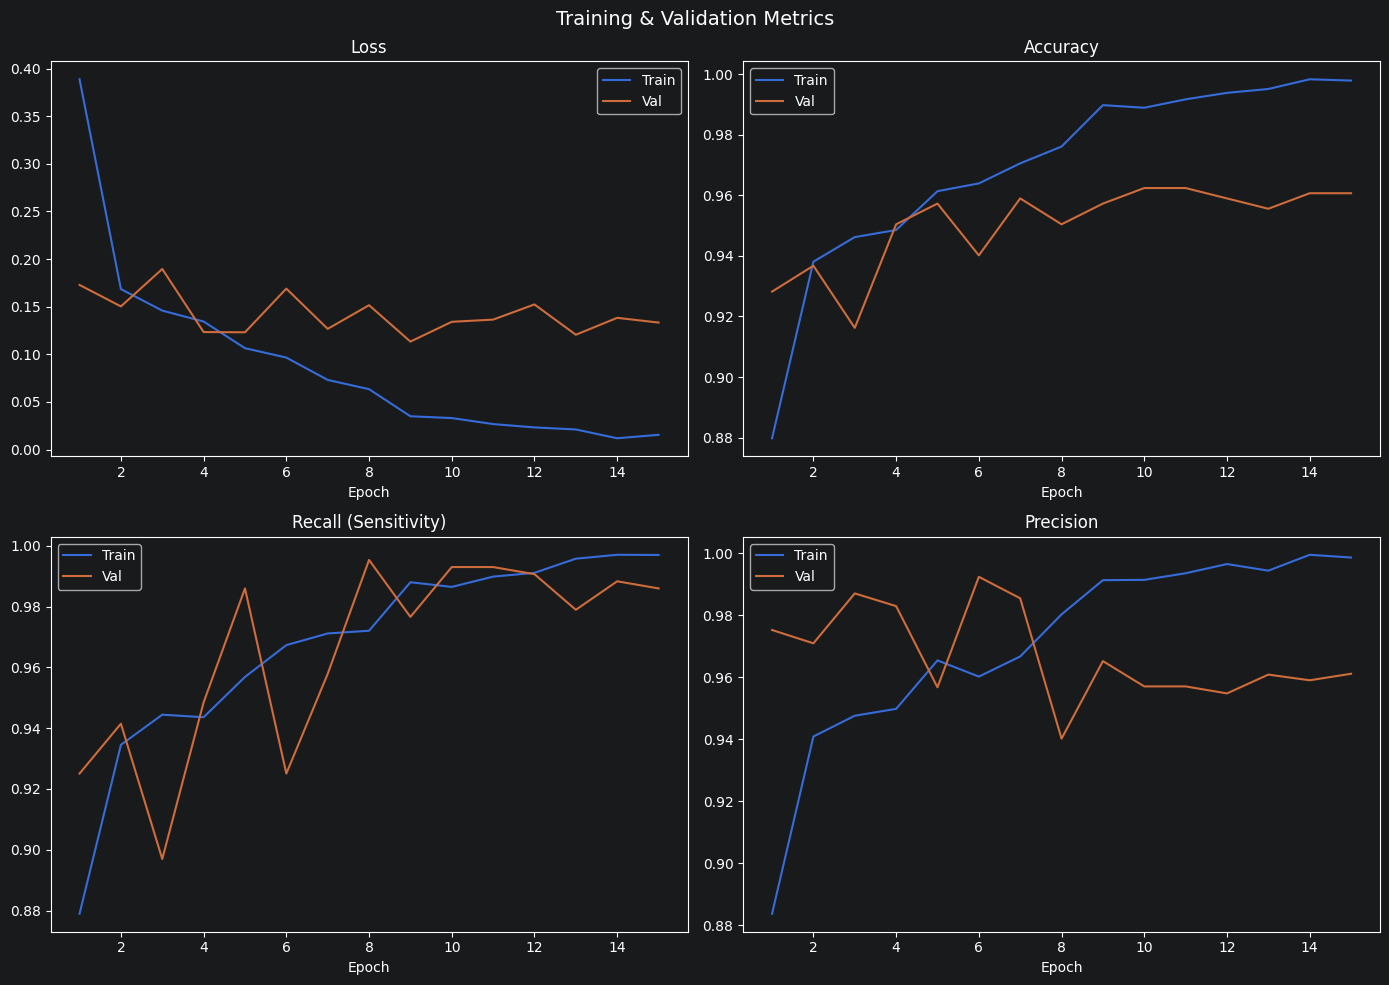

In [18]:
# Plot training curves: loss, accuracy, recall, precision
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, NUM_EPOCHS+1)

# Loss
axes[0, 0].plot(epochs_range, history["train_loss"], label="Train")
axes[0, 0].plot(epochs_range, history["val_loss"], label="Val")
axes[0, 0].set_title("Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

# Accuracy
axes[0, 1].plot(epochs_range, history["train_acc"], label="Train")
axes[0, 1].plot(epochs_range, history["val_acc"], label="Val")
axes[0, 1].set_title("Accuracy")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].legend()

# Recall (Sensitivity)
axes[1, 0].plot(epochs_range, history["train_recall"], label="Train")
axes[1, 0].plot(epochs_range, history["val_recall"], label="Val")
axes[1, 0].set_title("Recall (Sensitivity)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()

# Precision
axes[1, 1].plot(epochs_range, history["train_precision"], label="Train")
axes[1, 1].plot(epochs_range, history["val_precision"], label="Val")
axes[1, 1].set_title("Precision")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()

plt.suptitle("Training & Validation Metrics", fontsize=14)
plt.tight_layout()
plt.show()

**Hyperparameter Tuning via Random Search**

Following project guideline §4 we tune three hyperparameters: **learning rate**, **dropout**, and **weight decay**. We use **AdamW** instead of Adam — AdamW correctly decouples weight decay from the gradient update, meaning it only regularises the actual weight matrices and *not* the BatchNorm scale/bias parameters (which are scale-invariant and should not be penalised). This makes weight decay safe and effective to include in the search. All trials also use a **ReduceLROnPlateau** scheduler (factor=0.5, patience=2).

We run **20 trials** in total — trial 1 is the project's default config (so the comparison "tuned vs default" is honest) and trials 2–20 are sampled from:

- `lr` ∈ log-uniform[1e-5, 1e-3]
- `dropout` ∈ uniform[0.2, 0.6]
- `weight_decay` ∈ log-uniform[1e-5, 1e-2]

Each trial trains for the **full `NUM_EPOCHS` (15)** with **early stopping** (patience = 3 on validation AUC). Using the same epoch budget as the baseline ensures the search ranking reflects real full-training performance.

**Why rank by AUC?** AUC measures the whole ROC curve and is threshold-independent, making it a robust ranking signal that is not sensitive to the choice of classification threshold. It captures the model's overall discriminative ability across all operating points.

Estimated runtime: ~25–35 minutes on an RTX 5070 with the GPU-cached dataset.

In [19]:
import random as py_random
import gc
import pandas as pd

from sklearn.metrics import roc_auc_score as _roc_auc_score

# === Search configuration ===
SEARCH_EPOCHS         = NUM_EPOCHS  # Match the full training length so search ranking is reliable
EARLY_STOP_PATIENCE   = 3           # Stop a trial if val AUC hasn't improved for N epochs
N_RANDOM_TRIALS       = 19          # 19 random samples + 1 default baseline = 20 trials total
SEARCH_SEED           = 42          # Reproducible search

def sample_config(rng):
    """Sample one hyperparameter configuration from the search space."""
    return {
        "lr":           10 ** rng.uniform(-5, -3),   # log-uniform 1e-5 .. 1e-3
        "dropout":      rng.uniform(0.2, 0.6),       # uniform 0.2 .. 0.6
        "weight_decay": 10 ** rng.uniform(-5, -2),   # log-uniform 1e-5 .. 1e-2
        "batch_size": rng.choice([16, 32, 64])
    }

def build_model_with_dropout(p):
    """Fresh PneumoniaCNN with the requested dropout, on the right device."""
    m = PneumoniaCNN()
    for mod in m.modules():
        if isinstance(mod, nn.Dropout):
            mod.p = float(p)
    return m.to(device)

def train_one_trial(cfg):
    """Train one random-search trial and return the best val AUC achieved."""
    m    = build_model_with_dropout(cfg["dropout"])
    crit = nn.CrossEntropyLoss()
    # AdamW decouples weight decay from the gradient update — safe to use with BatchNorm
    opt  = torch.optim.AdamW(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=2
    )
    # Mixed-precision scaler — no-op on CPU/MPS, speeds up CUDA training
    # GradScaler only supports CUDA; on MPS/CPU we disable it (enabled=False makes it a no-op)
    amp_device = device.type if device.type == "cuda" else "cpu"
    scaler = torch.amp.GradScaler(amp_device, enabled=(device.type == "cuda"))

    # Per-trial DataLoader with the sampled batch size
    trial_loader = DataLoader(
        train_dataset,
        batch_size=cfg["batch_size"],
        sampler=sampler,
        **loader_kwargs,
    )

    best_auc, no_improve = 0.0, 0
    for epoch in range(SEARCH_EPOCHS):
        # Train with automatic mixed precision (fp16 on CUDA, fp32 elsewhere)
        m.train()
        for images, labels in trial_loader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                loss = crit(m(images), labels)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        # Validate — rank by AUC (threshold-independent, robust ranking signal)
        m.eval()
        v_labels, v_probs = [], []
        val_loss_accum = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = m(images)
                val_loss_accum += crit(outputs, labels).item() * images.size(0)
                v_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
                v_labels.extend(labels.cpu().numpy())
        val_loss = val_loss_accum / len(val_dataset)
        sched.step(val_loss)  # Step scheduler on validation loss
        # AUC on validation set; handles edge case where only one class present
        try:
            auc = _roc_auc_score(v_labels, v_probs)
        except ValueError:
            auc = 0.0

        # Early stopping on val AUC
        if auc > best_auc:
            best_auc, no_improve = auc, 0
        else:
            no_improve += 1
            if no_improve >= EARLY_STOP_PATIENCE:
                break

    # Free GPU memory before next trial
    del m, opt, sched, scaler, trial_loader
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()
    return best_auc

# === Build the trial schedule ===
# Trial 0 = the project default (lr=1e-4, dropout=0.4, weight_decay=0). Including it
# guarantees that "tuned vs default" comparison in the paper is honest.
search_rng     = py_random.Random(SEARCH_SEED)
DEFAULT_CONFIG = {"lr": 1e-4, "dropout": 0.4, "weight_decay": 0.0, "batch_size": 32}
trial_configs  = [DEFAULT_CONFIG] + [sample_config(search_rng) for _ in range(N_RANDOM_TRIALS)]

# === Run all trials ===
print(f"Running {len(trial_configs)} trials × up to {SEARCH_EPOCHS} epochs each...\n")
search_start = time.time()
results = []

for i, cfg in enumerate(trial_configs):
    trial_label = "default" if i == 0 else f"random-{i}"
    print(f"[{i+1:2d}/{len(trial_configs)}] {trial_label:>10s}  "
          f"lr={cfg['lr']:.2e}  dropout={cfg['dropout']:.3f}  wd={cfg['weight_decay']:.1e}  bs={cfg['batch_size']}")
    val_auc = train_one_trial(cfg)
    results.append({"trial": trial_label, **cfg, "val_auc": val_auc})
    print(f"             → val AUC = {val_auc:.4f}")

print(f"\nSearch finished in {(time.time() - search_start) / 60:.1f} minutes.")

Running 20 trials × up to 15 epochs each...

[ 1/20]    default  lr=1.00e-04  dropout=0.400  wd=0.0e+00  bs=32
             → val AUC = 0.9916
[ 2/20]   random-1  lr=1.90e-04  dropout=0.210  wd=6.7e-05  bs=16
             → val AUC = 0.9895
[ 3/20]   random-2  lr=1.90e-05  dropout=0.241  wd=1.7e-03  bs=64
             → val AUC = 0.9924
[ 4/20]   random-3  lr=1.49e-05  dropout=0.369  wd=1.2e-05  bs=16
             → val AUC = 0.9883
[ 5/20]   random-4  lr=2.92e-05  dropout=0.441  wd=4.8e-04  bs=64
             → val AUC = 0.9908
[ 6/20]   random-5  lr=1.99e-04  dropout=0.418  wd=4.6e-05  bs=64
             → val AUC = 0.9923
[ 7/20]   random-6  lr=3.60e-05  dropout=0.548  wd=1.9e-03  bs=16
             → val AUC = 0.9892
[ 8/20]   random-7  lr=2.49e-04  dropout=0.336  wd=2.9e-05  bs=32
             → val AUC = 0.9919
[ 9/20]   random-8  lr=1.60e-05  dropout=0.352  wd=1.2e-04  bs=32
             → val AUC = 0.9908
[10/20]   random-9  lr=1.61e-04  dropout=0.523  wd=1.5e-03  bs=64
       

**Search results — sorted by validation AUC**

The winning configuration is rank 0. We always include the default config so the table directly answers "did random search beat the default?". Because each trial trains for the full `NUM_EPOCHS`, the ranking is directly comparable to the baseline.

In [20]:
# Sort trials by validation AUC, with rank 0 = best
results_df = (
    pd.DataFrame(results)
      .sort_values("val_auc", ascending=False)
      .reset_index(drop=True)
)
results_df.index.name = "rank"

# Pretty-printed view (scientific notation for lr and weight_decay)
display_df = pd.DataFrame({
    "trial":        results_df["trial"],
    "lr":           results_df["lr"].apply(lambda x: f"{x:.2e}"),
    "dropout":      results_df["dropout"].apply(lambda x: f"{x:.3f}"),
    "weight_decay": results_df["weight_decay"].apply(lambda x: f"{x:.1e}"),
    "batch_size":   results_df["batch_size"].apply(lambda x: str(int(x))),
    "val_auc":      results_df["val_auc"].apply(lambda x: f"{x:.4f}"),
})
display_df.index = results_df.index
print("Random Search Results (sorted by val AUC):\n")
print(display_df.to_string())

# Compare best vs default
best_cfg    = results_df.iloc[0]
default_row = results_df[results_df["trial"] == "default"].iloc[0]
delta       = best_cfg["val_auc"] - default_row["val_auc"]
delta_pct   = (delta / default_row["val_auc"]) * 100 if default_row["val_auc"] > 0 else 0

print(f"\nBest config:    val AUC = {best_cfg['val_auc']:.4f}  ({best_cfg['trial']})")
print(f"Default config: val AUC = {default_row['val_auc']:.4f}")
print(f"Improvement:    {delta:+.4f}  ({delta_pct:+.2f}%)")

Random Search Results (sorted by val AUC):

          trial        lr dropout weight_decay batch_size val_auc
rank                                                             
0     random-15  5.14e-05   0.468      1.3e-03         64  0.9925
1      random-2  1.90e-05   0.241      1.7e-03         64  0.9924
2      random-5  1.99e-04   0.418      4.6e-05         64  0.9923
3     random-16  1.98e-04   0.444      3.3e-05         64  0.9919
4      random-7  2.49e-04   0.336      2.9e-05         32  0.9919
5       default  1.00e-04   0.400      0.0e+00         32  0.9916
6     random-10  1.78e-05   0.569      1.7e-05         32  0.9914
7     random-17  3.09e-05   0.385      6.5e-05         64  0.9914
8     random-12  2.42e-05   0.228      9.6e-04         32  0.9913
9      random-9  1.61e-04   0.523      1.5e-03         64  0.9910
10     random-8  1.60e-05   0.352      1.2e-04         32  0.9908
11     random-4  2.92e-05   0.441      4.8e-04         64  0.9908
12    random-19  2.87e-05   0.21

**Retrain the winning configuration**

We retrain the winner from scratch with **best-model checkpointing** (saving the epoch with the lowest val loss) and the same **ReduceLROnPlateau** scheduler — exactly the same protocol as the baseline, only the learning rate, dropout, and weight decay differ. We use **AdamW** here too, consistent with the search trials.

This gives us **Run 1 tuned**, which we'll later compare against **Run 1 baseline** and (when ready) **Run 2** — the same tuned config trained on the artifact-removed dataset.

In [21]:
# === Retrain the winning configuration for the full NUM_EPOCHS, with best-model checkpointing ===
best_lr           = float(best_cfg["lr"])
best_dropout      = float(best_cfg["dropout"])
best_weight_decay = float(best_cfg["weight_decay"])

best_batch_size   = int(best_cfg["batch_size"])

print(f"Retraining best config for {NUM_EPOCHS} epochs:")
print(f"  lr={best_lr:.2e}  dropout={best_dropout:.3f}  weight_decay={best_weight_decay:.1e}  batch_size={best_batch_size}\n")

tuned_model     = build_model_with_dropout(best_dropout)
tuned_criterion = nn.CrossEntropyLoss()
# AdamW: weight decay is decoupled from gradient update — safe with BatchNorm
tuned_optimizer = torch.optim.AdamW(tuned_model.parameters(), lr=best_lr, weight_decay=best_weight_decay)
tuned_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    tuned_optimizer, mode="min", factor=0.5, patience=2
)
# Mixed-precision scaler for the retrain — no-op on CPU/MPS
# GradScaler only supports CUDA; on MPS/CPU we disable it (enabled=False makes it a no-op)
amp_device = device.type if device.type == "cuda" else "cpu"
tuned_scaler = torch.amp.GradScaler(amp_device, enabled=(device.type == "cuda"))

# DataLoader with the winning batch size
tuned_train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch_size,
    sampler=sampler,
    **loader_kwargs,
)

# Same per-epoch metric tracking as the baseline run, so plots are directly comparable.
tuned_history = {k: [] for k in history.keys()}
tuned_best_val_loss = float("inf")
tuned_best_weights  = None

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # --- Training phase ---
    tuned_model.train()
    running_loss = 0.0
    tr_preds, tr_labels = [], []
    for images, labels in tuned_train_loader:
        images, labels = images.to(device), labels.to(device)
        tuned_optimizer.zero_grad()
        with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
            outputs = tuned_model(images)
            loss = tuned_criterion(outputs, labels)
        tuned_scaler.scale(loss).backward()
        tuned_scaler.step(tuned_optimizer)
        tuned_scaler.update()
        running_loss += loss.item() * images.size(0)
        tr_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
        tr_labels.extend(labels.cpu().numpy())
    train_loss = running_loss / len(train_dataset)
    tr_acc, tr_recall, tr_prec = compute_metrics(tr_labels, tr_preds)

    # --- Validation phase ---
    tuned_model.eval()
    val_running_loss = 0.0
    v_preds, v_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = tuned_model(images)
            loss = tuned_criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            v_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            v_labels.extend(labels.cpu().numpy())
    val_loss = val_running_loss / len(val_dataset)
    v_acc, v_recall, v_prec = compute_metrics(v_labels, v_preds)

    # Step the learning rate scheduler
    tuned_scheduler.step(val_loss)

    # Save metrics
    for key, value in [
        ("train_loss", train_loss), ("val_loss", val_loss),
        ("train_acc", tr_acc), ("val_acc", v_acc),
        ("train_recall", tr_recall), ("val_recall", v_recall),
        ("train_precision", tr_prec), ("val_precision", v_prec),
    ]:
        tuned_history[key].append(value)

    # Save best
    if val_loss < tuned_best_val_loss:
        tuned_best_val_loss = val_loss
        tuned_best_weights  = copy.deepcopy(tuned_model.state_dict())

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({elapsed:.1f}s) | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} "
          f"Val Acc: {v_acc:.3f} Val Recall: {v_recall:.3f}")

tuned_model.load_state_dict(tuned_best_weights)
print(f"\nTuned model restored at best val_loss = {tuned_best_val_loss:.4f}")

Retraining best config for 15 epochs:
  lr=5.14e-05  dropout=0.468  weight_decay=1.3e-03  batch_size=64

Epoch 1/15 (4.4s) | Train Loss: 0.3901 | Val Loss: 0.1826 Val Acc: 0.925 Val Recall: 0.923
Epoch 2/15 (4.3s) | Train Loss: 0.1761 | Val Loss: 0.1501 Val Acc: 0.942 Val Recall: 0.934
Epoch 3/15 (4.3s) | Train Loss: 0.1570 | Val Loss: 0.1177 Val Acc: 0.957 Val Recall: 0.979
Epoch 4/15 (4.1s) | Train Loss: 0.1236 | Val Loss: 0.2039 Val Acc: 0.925 Val Recall: 0.904
Epoch 5/15 (4.2s) | Train Loss: 0.1254 | Val Loss: 0.1202 Val Acc: 0.962 Val Recall: 0.965
Epoch 6/15 (4.2s) | Train Loss: 0.1106 | Val Loss: 0.1090 Val Acc: 0.961 Val Recall: 0.967
Epoch 7/15 (4.2s) | Train Loss: 0.0891 | Val Loss: 0.1428 Val Acc: 0.944 Val Recall: 0.993
Epoch 8/15 (4.2s) | Train Loss: 0.0832 | Val Loss: 0.1095 Val Acc: 0.962 Val Recall: 0.979
Epoch 9/15 (4.2s) | Train Loss: 0.0659 | Val Loss: 0.1133 Val Acc: 0.966 Val Recall: 0.979
Epoch 10/15 (4.3s) | Train Loss: 0.0531 | Val Loss: 0.1050 Val Acc: 0.968 Va

**Final Evaluation on Test Set**

This is the **only** place in the notebook where the held-out test set is used for evaluation. Neither the baseline nor the tuned model has seen these images during training or hyperparameter selection. We evaluate both models side-by-side so the comparison is fair.

**Important:** The optimal classification threshold is computed on the **validation set** (not the test set) to avoid data leakage. We then apply that threshold to the test set predictions.

In [22]:
# === Evaluate BOTH models on the held-out test set ===
# This is the ONLY cell that touches the test set for evaluation.

def evaluate_on_test(m, loader, label="Model"):
    """Run a model on the test loader and return preds, labels, probs."""
    m.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = m(images)
            all_probs.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

# Baseline model
baseline_preds, test_labels, baseline_probs = evaluate_on_test(model, test_loader, "Baseline")
baseline_auc = roc_auc_score(test_labels, baseline_probs)

# Tuned model
tuned_preds, _, tuned_probs = evaluate_on_test(tuned_model, test_loader, "Tuned")
tuned_auc = roc_auc_score(test_labels, tuned_probs)

print(f"Baseline test AUC: {baseline_auc:.4f}")
print(f"Tuned    test AUC: {tuned_auc:.4f}")
print(f"Improvement:       {tuned_auc - baseline_auc:+.4f}")

Baseline test AUC: 0.9870
Tuned    test AUC: 0.9874
Improvement:       +0.0005


**Confusion Matrices — Baseline vs Tuned**

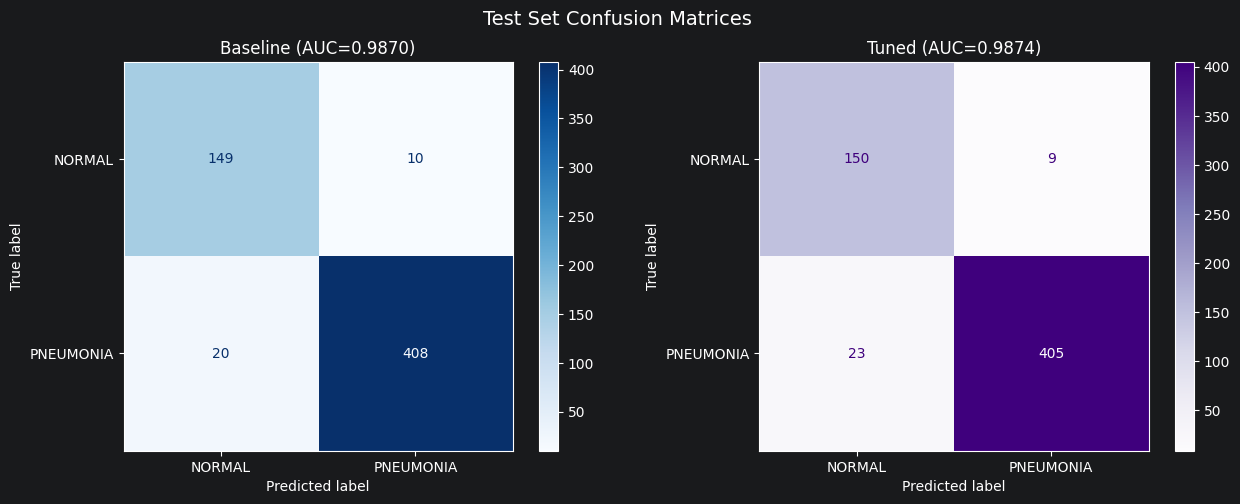


Baseline Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.88      0.94      0.91       159
   PNEUMONIA       0.98      0.95      0.96       428

    accuracy                           0.95       587
   macro avg       0.93      0.95      0.94       587
weighted avg       0.95      0.95      0.95       587


Tuned Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.94      0.90       159
   PNEUMONIA       0.98      0.95      0.96       428

    accuracy                           0.95       587
   macro avg       0.92      0.94      0.93       587
weighted avg       0.95      0.95      0.95       587



In [23]:
# Side-by-side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

cm_base = confusion_matrix(test_labels, baseline_preds, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=classes).plot(ax=ax1, cmap="Blues")
ax1.set_title(f"Baseline (AUC={baseline_auc:.4f})")

cm_tuned = confusion_matrix(test_labels, tuned_preds, labels=[0, 1])
ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=classes).plot(ax=ax2, cmap="Purples")
ax2.set_title(f"Tuned (AUC={tuned_auc:.4f})")

plt.suptitle("Test Set Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

print("\nBaseline Classification Report:")
print(classification_report(test_labels, baseline_preds, target_names=classes))
print("\nTuned Classification Report:")
print(classification_report(test_labels, tuned_preds, target_names=classes))

**ROC Curves — Baseline vs Tuned**

The ROC curve shows the trade-off between sensitivity (recall) and specificity at various thresholds.

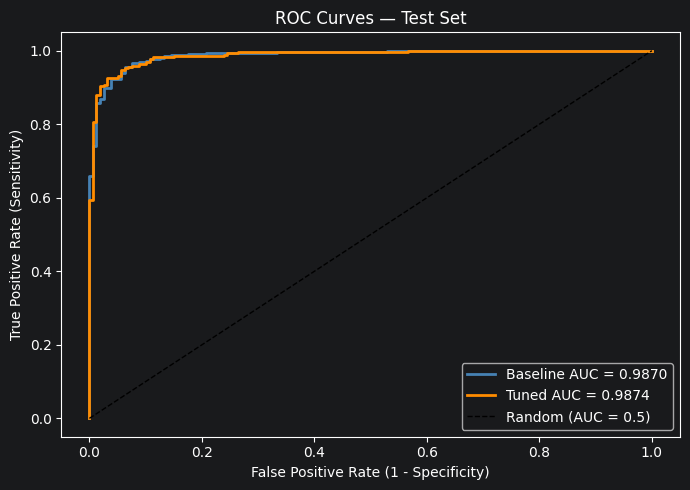

In [24]:
# ROC curves for both models
fpr_base, tpr_base, _ = roc_curve(test_labels, baseline_probs)
fpr_tuned, tpr_tuned, _ = roc_curve(test_labels, tuned_probs)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_base, tpr_base, label=f"Baseline AUC = {baseline_auc:.4f}", color="steelblue", lw=2)
ax.plot(fpr_tuned, tpr_tuned, label=f"Tuned AUC = {tuned_auc:.4f}", color="darkorange", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curves — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Threshold Tuning (computed on Validation Set)**

We find the optimal classification threshold using Youden's J statistic on the **validation set** to avoid data leakage. The threshold is then applied to the test set predictions for the final confusion matrix. This ensures the test set remains truly held-out.

Optimal threshold (Youden's J on validation set): 0.8429
  TPR (Sensitivity) at threshold: 0.9321
  FPR at threshold: 0.0190


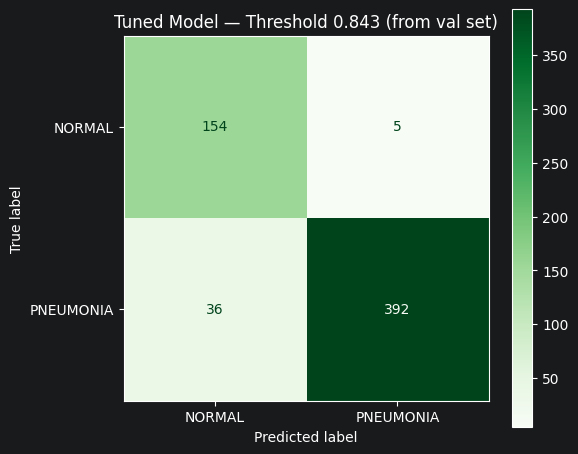


Classification Report at Optimal Threshold:
              precision    recall  f1-score   support

      NORMAL       0.81      0.97      0.88       159
   PNEUMONIA       0.99      0.92      0.95       428

    accuracy                           0.93       587
   macro avg       0.90      0.94      0.92       587
weighted avg       0.94      0.93      0.93       587



In [25]:
# === Compute optimal threshold on the VALIDATION set (not test!) ===
# This prevents data leakage — the test set stays untouched for threshold selection.

# Get validation probabilities from the tuned model
tuned_model.eval()
val_probs_for_threshold, val_labels_for_threshold = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = tuned_model(images)
        val_probs_for_threshold.extend(F.softmax(outputs, dim=1)[:, 1].cpu().numpy())
        val_labels_for_threshold.extend(labels.cpu().numpy())
val_probs_arr = np.array(val_probs_for_threshold)
val_labels_arr = np.array(val_labels_for_threshold)

# Youden's J on validation set
fpr_val, tpr_val, thresholds_val = roc_curve(val_labels_arr, val_probs_arr)
j_scores = tpr_val - fpr_val
best_idx = np.argmax(j_scores)
best_threshold = thresholds_val[best_idx]

print(f"Optimal threshold (Youden's J on validation set): {best_threshold:.4f}")
print(f"  TPR (Sensitivity) at threshold: {tpr_val[best_idx]:.4f}")
print(f"  FPR at threshold: {fpr_val[best_idx]:.4f}")

# Apply the validation-derived threshold to the TEST set
tuned_preds_thresholded = (tuned_probs >= best_threshold).astype(int)
cm_thresholded = confusion_matrix(test_labels, tuned_preds_thresholded, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_thresholded, display_labels=classes)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Greens")
ax.set_title(f"Tuned Model — Threshold {best_threshold:.3f} (from val set)")
plt.tight_layout()
plt.show()

print("\nClassification Report at Optimal Threshold:")
print(classification_report(test_labels, tuned_preds_thresholded, target_names=classes))

In [26]:
import joblib

# Save the tuned model (best performing)
joblib.dump(tuned_model, "CNN.pkl")
print("Tuned model saved to CNN.pkl")

Tuned model saved to CNN.pkl
